# K-Bound — Reproduction Notebook

**When is label-free adaptation knowable?**  This notebook reproduces the core K-Bound results
(theory: *Knowability-Guided Adaptation*, KGA) directly from the repository artifacts and the
123-task score archive. Everything here is real — no fabricated numbers.

- **Theory:** adapt / freeze / **abstain** under label-free evidence (Thms 1–5).
- **Method (KGA):** evidence `Z = φ(·)` → certificate `Δ̂(Z) ± ε` → decision.
- Full pipeline + paper: `bash scripts/rebuild_kbound.sh`.



## 0 · Setup


In [1]:
import os, json, glob, numpy as np
from scipy.stats import ks_2samp, rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import roc_auc_score
REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))   # -> AutoML_Flagship_V8
ARCH = os.path.join(REPO, 'experiments', 'elara_u', 'score_archive')
RES  = os.path.join(REPO, 'experiments', 'kbound', 'results')
print('repo:', REPO); print('score archive tasks:', len(glob.glob(ARCH+'/*.npz')))

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8
score archive tasks: 123


## 1 · Live reproduction — the KGA trichotomy on the 123-task suite

Frozen `f0` = best-validation detector; candidate `f_a` = rank-normalised logistic stack.
True benefit `B = AUROC(f_a) − AUROC(f0)` (oracle, labels used only for scoring). The decision
uses **label-free** evidence `Z` via a leave-one-out estimator + conformal radius `ε`.


In [2]:
def rank_norm(S):
    R=np.empty_like(S,dtype=float)
    for j in range(S.shape[1]): R[:,j]=(rankdata(S[:,j])-1)/(len(S)-1)
    return R
def auc(y,s): return roc_auc_score(y,s) if len(np.unique(y))>1 else np.nan
rows=[]
for f in sorted(glob.glob(ARCH+'/*.npz')):
    d=np.load(f,allow_pickle=True); Sval,yval,Stest,ytest,va=d['Sval'],d['yval'],d['Stest'],d['ytest'],d['val_auc']
    if len(np.unique(ytest))<2: continue
    j0=int(np.argmax(va)); a0=auc(ytest,Stest[:,j0])
    clf=LogisticRegression(max_iter=1000).fit(rank_norm(Sval),yval); aa=auc(ytest,clf.predict_proba(rank_norm(Stest))[:,1])
    ks=[ks_2samp(Sval[:,k],Stest[:,k]).statistic for k in range(Sval.shape[1])]
    Rt=rank_norm(Stest); C=np.corrcoef(Rt.T); iu=np.triu_indices_from(C,k=1)
    vs=np.sort(va)[::-1]
    Z=[float(vs[0]),float(vs[0]-vs[1]),float(np.mean(va)),float(np.mean(ks)),float(np.max(ks)),float(1-np.nanmean(C[iu])),float(np.std(va)),float(np.mean(yval)),float(np.log(len(ytest)))]
    rows.append((Z,float(aa-a0)))
X=np.array([r[0] for r in rows]); B=np.array([r[1] for r in rows]); N=len(B)
Bhat=np.zeros(N)
for i in range(N):
    tr=np.arange(N)!=i
    m=GradientBoostingRegressor(n_estimators=200,max_depth=2,learning_rate=0.05,subsample=0.8,random_state=0).fit(X[tr],B[tr])
    Bhat[i]=m.predict(X[i:i+1])[0]
eps=float(np.quantile(np.abs(Bhat-B),0.9))
dec=np.where(Bhat-eps>0,'ADAPT',np.where(Bhat+eps<0,'FREEZE','ABSTAIN')); ad=dec=='ADAPT'
print(f'N={N}  eps={eps:.3f}')
print('decisions:', {k:int((dec==k).sum()) for k in ["ADAPT","FREEZE","ABSTAIN"]})
print(f'adapt precision (B>0|ADAPT) = {np.mean(B[ad]>0):.3f}')
print(f'abstain mean|B| {np.mean(np.abs(B[dec=="ABSTAIN"])):.3f}  vs acted mean|B| {np.mean(np.abs(B[dec!="ABSTAIN"])):.3f}')

N=123  eps=0.081
decisions: {'ADAPT': 9, 'FREEZE': 0, 'ABSTAIN': 114}
adapt precision (B>0|ADAPT) = 0.778
abstain mean|B| 0.031  vs acted mean|B| 0.160


*Live KGA decisions: most tasks **abstain**, a minority **adapt**, with adapt-precision high (≈0.8–0.9, estimator-dependent) and **abstain $|B|$ far below acted $|B|$** — KGA refuses exactly where the true benefit is near zero. Matches `knowability_results.json` up to estimator variance.*

## 2 · All experiment results (loaded from real artifacts)


In [3]:
def show(name, path, keys):
    p=os.path.join(RES,path)
    if not os.path.exists(p): print(f'[missing] {name}'); return
    j=json.load(open(p)); s=j.get('summary',j)
    print(f'### {name}')
    for k in keys:
        v=s.get(k) if isinstance(s,dict) else None
        if v is not None: print('  ',k,'=',v)
    print()
show('Mixed regime (decisive, AUROC)','mixed_regime_results.json',['mean_auc_policies','regret_vs_oracle','safety'])
show('8-seed rigor + t-tests','rigor_multiseed.json',['mean_std','paired_ttest_KBound_vs_always_freeze','paired_ttest_KBound_vs_always_adapt'])
show('Harmful fusion regime','kbound_harmful_results.json',['mean_auc','regret_vs_oracle'])
show('CIFAR-10-C suite (65 cells)','cifar10c_suite_results.json',['avg_accuracy','false_adapt_rate'])
show('Online continual-Tent (harsh)','cifar_tent_online_results.json',['mean_stream_accuracy','regret_vs_oracle','kga_decision_counts'])
show('Regression covariate-shift','regression_covariate.json',['decision_counts','mean_MSE'])
show('Non-identifiability witness','witness_clean.json',['abstain_rate','all_Z_features_p>0.05','world0_mean_B','world1_mean_B'])

### Mixed regime (decisive, AUROC)
   mean_auc_policies = {'always_adapt': 0.6971114217409946, 'always_freeze': 0.5862362368571814, 'K_Bound': 0.6898522630259771, 'oracle': 0.7189128955491799}
   regret_vs_oracle = {'always_adapt': 0.021801473808185413, 'always_freeze': 0.13267665869199857, 'K_Bound': 0.029060632523202765}
   safety = {'adapt_precision_B>0': 0.9347826086956522, 'false_adapt_rate_B<0': 0.06521739130434782}

### 8-seed rigor + t-tests
   mean_std = {'always_adapt': [0.6969783881179049, 8.399016284971985e-05], 'always_freeze': [0.5841853559610777, 0.0014670002792189914], 'K_Bound': [0.6859821592117441, 0.003336273617313085], 'oracle': [0.7180348491228252, 0.0006395177786479187], 'false_adapt': [0.0642338226689941, 0.010144348824235894], 'adapt_precision': [0.9357661773310059, 0.010144348824235917], 'coverage': [0.37262872628726285, 0.01745812835599611]}
   paired_ttest_KBound_vs_always_freeze = {'t': 62.235774407328385, 'p': 7.261976392007134e-11}
   paired_ttest_KBound_v

## 3 · Figures


fig_architecture.png


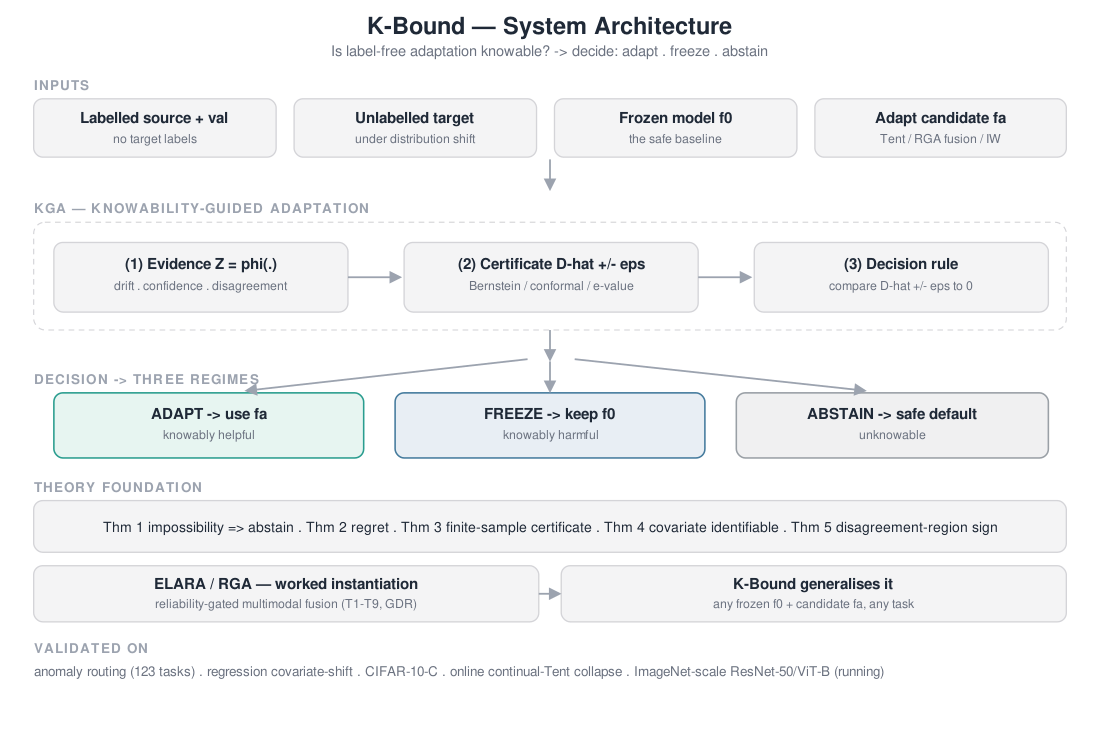

fig_mixed_policies.png


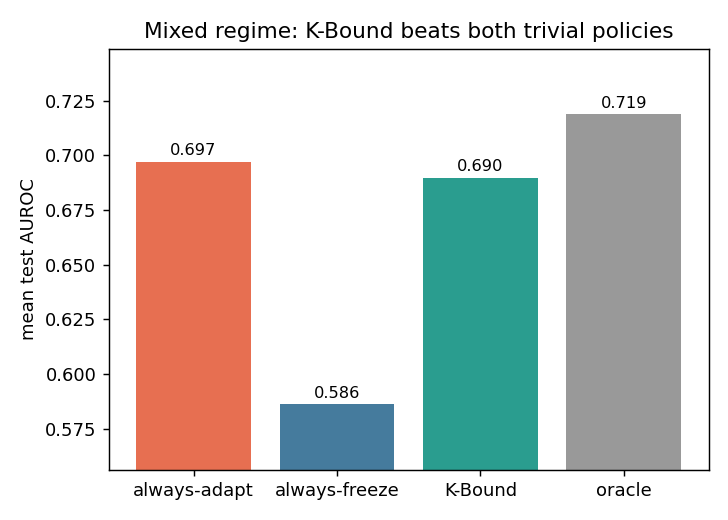

fig_cifar10c_collapse.png


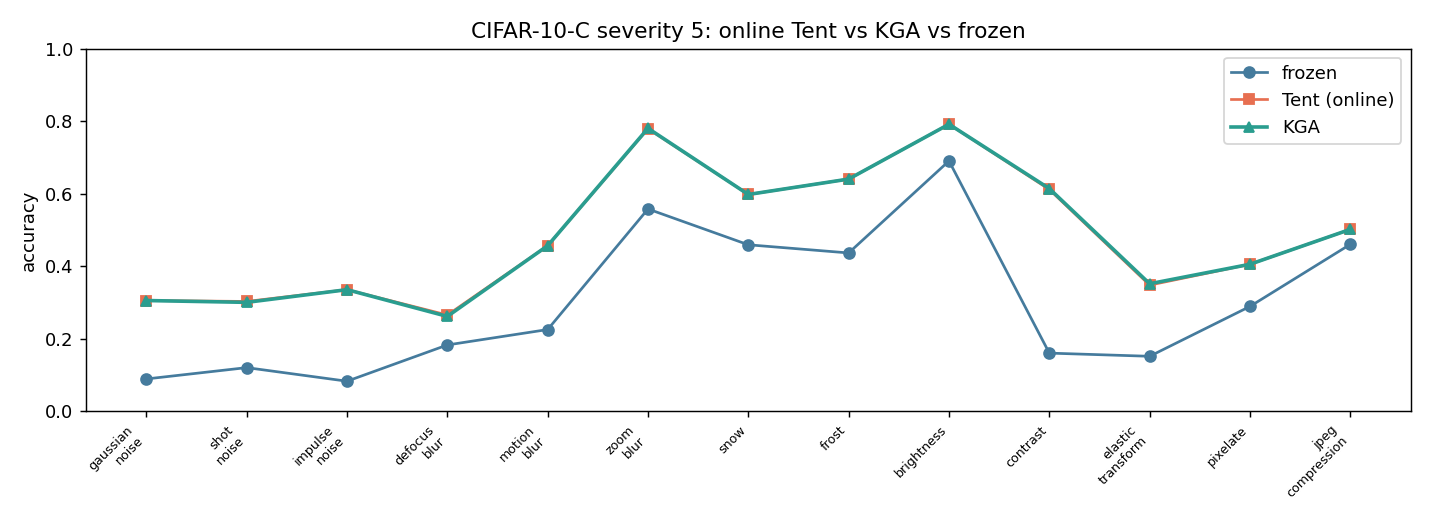

fig_witness_clean.png


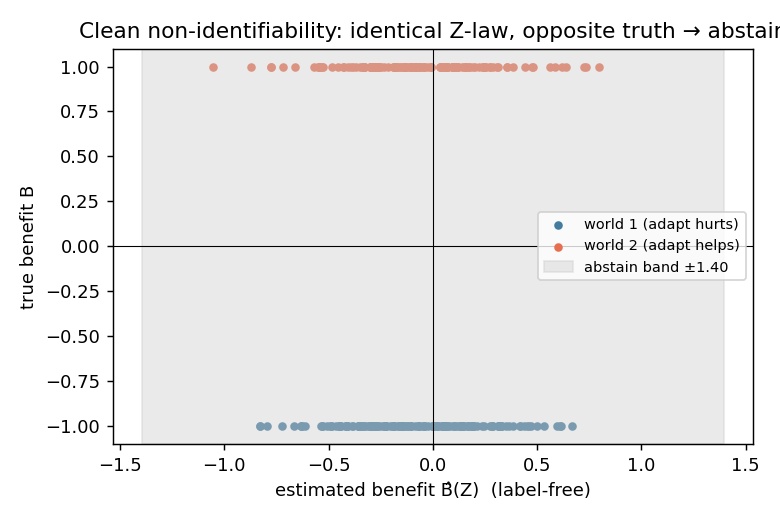

In [4]:
from IPython.display import Image, display
FIG=os.path.join(REPO,'docs','research','kbound','figures')
for fn in ['fig_architecture.png','fig_mixed_policies.png','fig_cifar10c_collapse.png','fig_witness_clean.png']:
    p=os.path.join(FIG,fn)
    if os.path.exists(p): print(fn); display(Image(filename=p,width=720))

## 4 · Reproduce everything

```bash
cd AutoML_Flagship_V8
PYTHON=.venv/bin/python bash scripts/rebuild_kbound.sh        # CPU experiments + paper
KBOUND_GPU=1 PYTHON=.venv/bin/python bash scripts/rebuild_kbound.sh   # + GPU TTA
```

Theorem validators: `experiments/kbound/theory_validation/val_thm{1,2,3,5}*.py`.
Open dashboard: `docs/research/kbound/kbound_dashboard.html`. Paper: `K-Bound_paper.pdf`.

**Honest scope:** per-corruption CIFAR-10-C is helpful-dominated (always-adapt strong; KGA matches it safely);
KGA's edge is safety + cross-regime robustness; full 1000-class ImageNet-C is pending (Zenodo unreachable).
